<a href="https://colab.research.google.com/github/twillixa/HEC/blob/main/PPS/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:

!pip install pulp numpy pandas matplotlib
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpBinary, value, LpStatus
from pulp import *


 ## Week1


In [2]:
def simulate_plan(
    demand,
    production_per_worker_regular,
    starting_inventory,
    desired_ending_inventory,
    initial_workers,
    wage_per_worker,
    hire_cost,
    layoff_cost,
    inventory_cost_per_unit,
    overtime_months,
    overtime_percentage,
    overtime_wage_multiplier,
    strategy,
):
    months = len(demand)
    overtime_months = set(overtime_months or [])
    demand = np.array(demand, dtype=float)

    # workforce arrays
    workers = np.zeros(months)
    hired = np.zeros(months)
    laid_off = np.zeros(months)
    inventory = np.zeros(months + 1)
    inventory[0] = starting_inventory

    # helper: overtime factor by month
    ot_flag = np.array([1.0 if t in overtime_months else 0.0 for t in range(months)])
    prod_per_worker = production_per_worker_regular * (1 + ot_flag * overtime_percentage)

    # choose workforce rule
    if strategy == "chase":
        workers_needed = np.ceil(demand / production_per_worker_regular)
    else:
        total_required = demand.sum() + desired_ending_inventory - starting_inventory
        total_capacity_per_worker = prod_per_worker.sum()
        w_const = int(np.ceil(total_required / total_capacity_per_worker))
        workers_needed = np.full(months, w_const)

    # simulate month-by-month
    for t in range(months):
        workers[t] = workers_needed[t]
        if t == 0:
            hired[t] = max(0, workers[t] - initial_workers)
            laid_off[t] = max(0, initial_workers - workers[t])
        else:
            hired[t] = max(0, workers[t] - workers[t-1])
            laid_off[t] = max(0, workers[t-1] - workers[t])
        produced = workers[t] * prod_per_worker[t]
        inventory[t+1] = inventory[t] + produced - demand[t]

    # costs
    wage_cost = workers * wage_per_worker
    hiring_cost = hired * hire_cost
    layoff_costs = laid_off * layoff_cost
    inv_cost = inventory[1:] * inventory_cost_per_unit
    overtime_cost = workers * wage_per_worker * (ot_flag * overtime_percentage) * overtime_wage_multiplier

    total_monthly = wage_cost + hiring_cost + layoff_costs + inv_cost + overtime_cost

    df = pd.DataFrame({
        "Month": np.arange(1, months+1),
        "Workers": workers,
        "Hired": hired,
        "Laid off": laid_off,
        "Produced": workers * prod_per_worker,
        "Demand": demand,
        "End Inventory": inventory[1:],
        "Wage Cost": wage_cost,
        "Overtime Cost": overtime_cost,
        "Hiring Cost": hiring_cost,
        "Layoff Cost": layoff_costs,
        "Inventory Cost": inv_cost,
        "Total Cost": total_monthly,
    })

    summary = {
        "Total Wage": float(wage_cost.sum()),
        "Total Overtime": float(overtime_cost.sum()),
        "Total Hiring": float(hiring_cost.sum()),
        "Total Layoff": float(layoff_costs.sum()),
        "Total Inventory": float(inv_cost.sum()),
        "Grand Total": float(total_monthly.sum()),
    }

    return df, summary

In [3]:
df_level, s_level = simulate_plan(
    demand                        = [300, 300, 350, 400, 450, 500, 650, 600, 475, 475, 450, 450],
    production_per_worker_regular = 10,
    starting_inventory            = 50,
    desired_ending_inventory      = 50,
    initial_workers               = 40,
    wage_per_worker               = 2,
    hire_cost                     = 1,
    layoff_cost                   = 2,
    inventory_cost_per_unit       = 0.06,
    overtime_months               = [5, 6, 7],
    overtime_percentage           = 0.2,
    overtime_wage_multiplier      = 1.5,
    strategy                      = "mixed",
)
display(df_level)
s_level

,Month,Workers,Hired,Laid off,Produced,Demand,End Inventory,Wage Cost,Overtime Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,1,43.0,3.0,0.0,430.0,300.0,180.0,86.0,0.0,3.0,0.0,10.80,99.80
1,2,43.0,0.0,0.0,430.0,300.0,310.0,86.0,0.0,0.0,0.0,18.60,104.60
2,3,43.0,0.0,0.0,430.0,350.0,390.0,86.0,0.0,0.0,0.0,23.40,109.40
3,4,43.0,0.0,0.0,430.0,400.0,420.0,86.0,0.0,0.0,0.0,25.20,111.20
4,5,43.0,0.0,0.0,430.0,450.0,400.0,86.0,0.0,0.0,0.0,24.00,110.00
5,6,43.0,0.0,0.0,516.0,500.0,416.0,86.0,25.8,0.0,0.0,24.96,136.76
6,7,43.0,0.0,0.0,516.0,650.0,282.0,86.0,25.8,0.0,0.0,16.92,128.72
7,8,43.0,0.0,0.0,516.0,600.0,198.0,86.0,25.8,0.0,0.0,11.88,123.68
8,9,43.0,0.0,0.0,430.0,475.0,153.0,86.0,0.0,0.0,0.0,9.18,95.18
9,10,43.0,0.0,0.0,430.0,475.0,108.0,86.0,0.0,0.0,0.0,6.48,92.48


{'Total Wage': 1032.0,
 'Total Overtime': 77.39999999999999,
 'Total Hiring': 3.0,
 'Total Layoff': 0.0,
 'Total Inventory': 180.78,
 'Grand Total': 1293.1799999999998}

In [4]:
def sensitivity(
    param_name,
    param_values,
    strategies,
    base_kwargs,
    plot=True
):
    rows = []
    for v in param_values:
        for strat in strategies:
            kwargs = dict(base_kwargs)
            kwargs[param_name] = v
            df, summary = simulate_plan(strategy=strat, **kwargs)
            rows.append({
                param_name: v,
                "Strategy": strat,
                "Total Cost": summary["Grand Total"]
            })
    out = pd.DataFrame(rows)
    pivot = out.pivot(index=param_name, columns="Strategy", values="Total Cost").reset_index()
    if plot:
        for strat in pivot.columns[1:]:
            plt.plot(pivot[param_name], pivot[strat], marker="o", label=strat)
        plt.xlabel(param_name)
        plt.ylabel("Total Cost")
        plt.grid(True)
        plt.legend()
        plt.show()
    return pivot

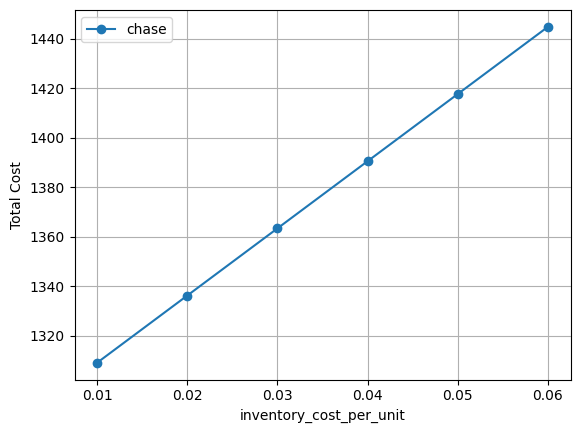

Strategy,inventory_cost_per_unit,chase
0,0.01,1309.15
1,0.02,1336.30
2,0.03,1363.45
3,0.04,1390.60
4,0.05,1417.75
5,0.06,1444.90


In [5]:


base = dict(
    demand=[300, 300, 350, 400, 450, 500, 650, 600, 475, 475, 450, 450],
    production_per_worker_regular=10,
    starting_inventory=50,
    desired_ending_inventory=50,
    initial_workers=40,
    wage_per_worker=2,
    hire_cost=1,
    layoff_cost=2,
    inventory_cost_per_unit=0.06,
    overtime_months=[5, 6, 7],
    overtime_percentage=0.2,
    overtime_wage_multiplier=1.5,
)

pivot_inv = sensitivity(
    param_name   = "inventory_cost_per_unit",
    param_values = [0.01,0.02,0.03,0.04,0.05,0.06],
    strategies   = ["chase"],
    base_kwargs  = base,
    plot         = True,
)
pivot_inv

In [6]:
#Jigsaw puzzle example
df_level, s_level = simulate_plan(
    demand                        = [600, 700, 400, 700, 500, 300],
    production_per_worker_regular = 100,
    starting_inventory            = 200,
    desired_ending_inventory      = 200,
    initial_workers               = 10,
    wage_per_worker               = 4,
    hire_cost                     = 1.5,
    layoff_cost                   = 4,
    inventory_cost_per_unit       = 0.05,
    overtime_months               = [0, 1],
    overtime_percentage           = 0.5,
    overtime_wage_multiplier      = 1.7,
    strategy                      = "chse",
)
display(df_level)
s_level
#Optimal strategy is level cost =291.5 vs chase=459.7

,Month,Workers,Hired,Laid off,Produced,Demand,End Inventory,Wage Cost,Overtime Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,1,5.0,0.0,5.0,750.0,600.0,350.0,20.0,17.0,0.0,20.0,17.5,74.5
1,2,5.0,0.0,0.0,750.0,700.0,400.0,20.0,17.0,0.0,0.0,20.0,57.0
2,3,5.0,0.0,0.0,500.0,400.0,500.0,20.0,0.0,0.0,0.0,25.0,45.0
3,4,5.0,0.0,0.0,500.0,700.0,300.0,20.0,0.0,0.0,0.0,15.0,35.0
4,5,5.0,0.0,0.0,500.0,500.0,300.0,20.0,0.0,0.0,0.0,15.0,35.0
5,6,5.0,0.0,0.0,500.0,300.0,500.0,20.0,0.0,0.0,0.0,25.0,45.0


{'Total Wage': 120.0,
 'Total Overtime': 34.0,
 'Total Hiring': 0.0,
 'Total Layoff': 20.0,
 'Total Inventory': 117.5,
 'Grand Total': 291.5}

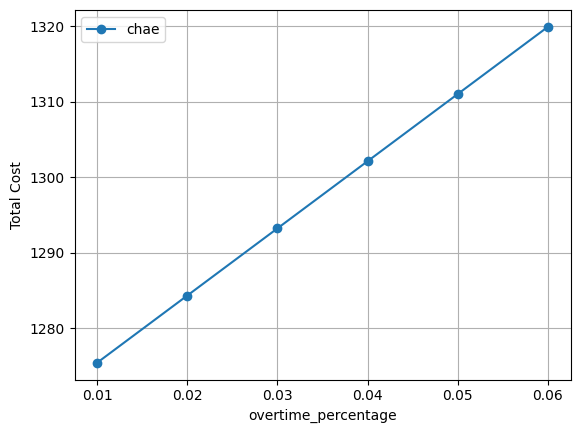

Strategy,overtime_percentage,chae
0,0.01,1275.41
1,0.02,1284.32
2,0.03,1293.23
3,0.04,1302.14
4,0.05,1311.05
5,0.06,1319.96


In [7]:
pivot_inv = sensitivity(
    param_name   = "overtime_percentage",
    param_values = [0.01,0.02,0.03,0.04,0.05,0.06],
    strategies   = ["chae"],
    base_kwargs  = base,
    plot         = True,
)
pivot_inv

 ## Week5

In [8]:
from IPython.terminal.magics import Magics
def solve_lsu(demand, p, q, h, s0=0):
  T=len(demand)

  prob=LpProblem("LSU",LpMinimize)

  x=[LpVariable(f'x_{t}',lowBound=0) for t in range(T)]
  y=[LpVariable(f'y_{t}',cat=LpBinary) for t in range(T)]
  s=[LpVariable(f's{t}',lowBound=0) for t in range(T)]

  prob+=lpSum([x[t]*p+q*y[t]] for t in range(T))+lpSum([s[t]*h for t in range(T-1)]) +s[T-1]*h/2

  M=sum(demand)

  for t in range(T):

    if t==0:

      prob+=x[t]+s0==demand[t]+s[t]

    else:

      prob+=x[t]+s[t-1]==demand[t]+s[t]

    prob+= x[t]<=y[t]*M





  prob.solve()

  production=[value(x[t]) for t in range(T)]
  inventory=[value(s[t]) for t in range(T)]
  setup=[value(y[t]) for t in range(T)]

  total_cost= value(prob.objective)

  df = pd.DataFrame({
        'Period': list(range(1, T+1)),
        'Demand': demand,
        'Production': production,
        'Inventory': inventory,
        'Setup': setup
    })

  return df, total_cost






In [9]:
p=100
q=5000
h=5
demand = [400, 400, 800, 800, 1200, 1200, 1200, 1200]
s0=200

result, total_cost = solve_lsu(demand, p, q, h, s0)

print(result)
print("Optimal total cost:", total_cost)

   Period  Demand  Production  Inventory  Setup
0       1     400       600.0      400.0    1.0
1       2     400         0.0        0.0    0.0
2       3     800      1600.0      800.0    1.0
3       4     800         0.0        0.0    0.0
4       5    1200      1200.0        0.0    1.0
5       6    1200      1200.0        0.0    1.0
6       7    1200      1200.0        0.0    1.0
7       8    1200      1200.0        0.0    1.0
Optimal total cost: 736000.0


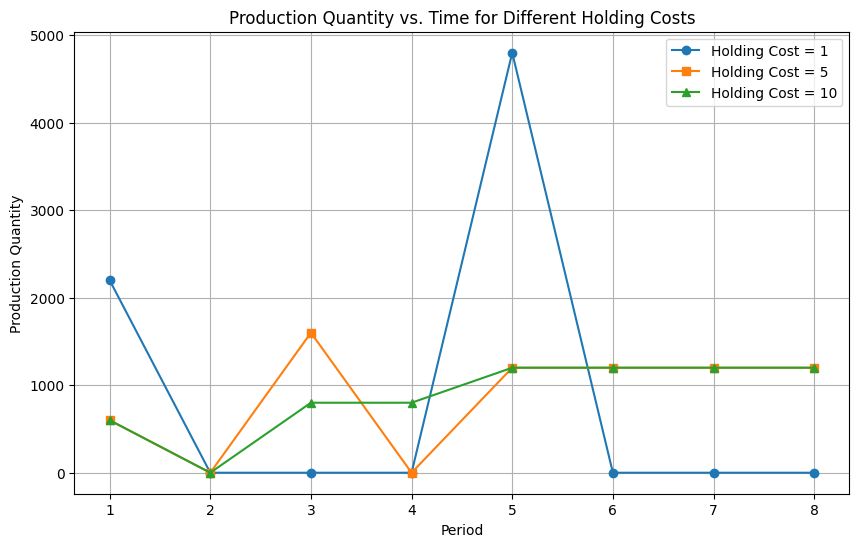

Optimal total cost for h = 1: 721600.0
Optimal total cost for h = 5: 736000.0
Optimal total cost for h = 10: 739000.0


In [10]:
plt.figure(figsize=(10, 6))

periods = list(range(1, 9))

result_1, cost_1 = solve_lsu(demand, p, q, 1, s0)
result_5, cost_5 = solve_lsu(demand, p, q, 5, s0)
result_10, cost_10 = solve_lsu(demand, p, q, 10, s0)

plt.plot(periods, result_1['Production'], marker='o', label='Holding Cost = 1')
plt.plot(periods, result_5['Production'], marker='s', label='Holding Cost = 5')
plt.plot(periods, result_10['Production'], marker='^', label='Holding Cost = 10')

plt.xlabel('Period')
plt.ylabel('Production Quantity')
plt.title('Production Quantity vs. Time for Different Holding Costs')
plt.legend()
plt.grid(True)
plt.show()

print("Optimal total cost for h = 1:", cost_1)
print("Optimal total cost for h = 5:", cost_5)
print("Optimal total cost for h = 10:", cost_10)

In [11]:
def solve_multi_lsu(demands, p_list, q_list, h_list, s0_list):

    I, T = len(demands), len(demands[0])

    prob = LpProblem('Multi_LS_U', LpMinimize)

    x = [[LpVariable(f'x_{i}_{t}', lowBound=0) for t in range(T)] for i in range(I)]
    s = [[LpVariable(f's_{i}_{t}', lowBound=0) for t in range(T)] for i in range(I)]
    y = [[LpVariable(f'y_{i}_{t}', cat=LpBinary) for t in range(T)] for i in range(I)]

    prob += lpSum([p_list[i] * x[i][t] + q_list[i] * y[i][t] for i in range(I) for t in range(T)]) + \
            lpSum([h_list[i] * s[i][t] for i in range(I) for t in range(T-1)]) + \
            lpSum([(h_list[i] / 2) * s[i][T-1] for i in range(I)])

    # Overall capacity constraint for each time period t, across all items
    for t in range(T):
        prob += lpSum([x[i][t] for i in range(I)]) <= 10000

    for i in range(I):
        M = sum(demands[i]) # Corrected indentation
        for t in range(T):
            if t == 0:
                prob += s0_list[i] + x[i][t] == demands[i][t] + s[i][t]
            else:
                prob += s[i][t-1] + x[i][t] == demands[i][t] + s[i][t]

            prob += x[i][t] <= M * y[i][t]

    prob.solve()

    results = {}
    for i in range(I):
        results[f'item_{i}'] = {
            'production': [value(x[i][t]) for t in range(T)],
            'inventory': [value(s[i][t]) for t in range(T)],
            'setup': [value(y[i][t]) for t in range(T)]
        }

    results['total_cost'] = value(prob.objective)
    results['status'] = LpStatus[prob.status]

    return results

In [12]:
demands = [
    [400, 400, 800, 800, 1200, 1200, 1200, 1200],  # City Scooters
    [200, 200, 200, 200, 200, 200, 500, 500]       # Off-Road Scooters pqhs
]

result = solve_multi_lsu(demands, [100, 60], [5000, 3000], [5, 3], [200, 0])

periods = list(range(1, 9))

city_df = pd.DataFrame({
    'Period': periods,
    'Production': result['item_0']['production'],
    'Inventory': result['item_0']['inventory'],
    'Setup': result['item_0']['setup']
})

offroad_df = pd.DataFrame({
    'Period': periods,
    'Production': result['item_1']['production'],
    'Inventory': result['item_1']['inventory'],
    'Setup': result['item_1']['setup']
})

print("City Scooters:")
print(city_df)

print("\nOff-Road Scooters:")
print(offroad_df)

print("\nOptimal total cost:", result['total_cost'])

City Scooters:
   Period  Production  Inventory  Setup
0       1       600.0      400.0    1.0
1       2         0.0        0.0    0.0
2       3      1600.0      800.0    1.0
3       4         0.0        0.0    0.0
4       5      1200.0        0.0    1.0
5       6      1200.0        0.0    1.0
6       7      1200.0        0.0    1.0
7       8      1200.0        0.0    1.0

Off-Road Scooters:
   Period  Production  Inventory  Setup
0       1       600.0      400.0    1.0
1       2         0.0      200.0    0.0
2       3         0.0        0.0    0.0
3       4       600.0      400.0    1.0
4       5         0.0      200.0    0.0
5       6         0.0        0.0    0.0
6       7      1000.0      500.0    1.0
7       8         0.0        0.0    0.0

Optimal total cost: 882100.0


In [13]:
demands = [
    [250, 250, 500, 500, 750, 750, 750, 750],  # COOKIEs
    [100, 150, 200, 250, 300, 350, 400, 450]       # brownieS
]

result = solve_multi_lsu(demands, [75, 45], [3500, 2000], [5, 3], [100, 0])

periods = list(range(1, 9))

city_df = pd.DataFrame({
    'Period': periods,
    'Production': result['item_0']['production'],
    'Inventory': result['item_0']['inventory'],
    'Setup': result['item_0']['setup']
})

offroad_df = pd.DataFrame({
    'Period': periods,
    'Production': result['item_1']['production'],
    'Inventory': result['item_1']['inventory'],
    'Setup': result['item_1']['setup']
})

print("Cookies:")
print(city_df)

print("\nBrownies:")
print(offroad_df)

print("\nOptimal total cost:", result['total_cost'])

Cookies:
   Period  Production  Inventory  Setup
0       1       400.0      250.0    1.0
1       2         0.0        0.0    0.0
2       3      1000.0      500.0    1.0
3       4         0.0        0.0    0.0
4       5       750.0        0.0    1.0
5       6       750.0        0.0    1.0
6       7       750.0        0.0    1.0
7       8       750.0        0.0    1.0

Brownies:
   Period  Production  Inventory  Setup
0       1       250.0      150.0    1.0
1       2         0.0        0.0    0.0
2       3       450.0      250.0    1.0
3       4         0.0        0.0    0.0
4       5       650.0      350.0    1.0
5       6         0.0        0.0    0.0
6       7       850.0      450.0    1.0
7       8         0.0        0.0    0.0

Optimal total cost: 465350.0


##Week6

In [11]:
def solve_multi_lsu_ss(demands, p_list, q_list, h_list, s0_list, ss_list):
    I, T = len(demands), len(demands[0])


    prob = LpProblem('Multi_LS_U_SS', LpMinimize)

    x = [[LpVariable(f'x_{i}_{t}', lowBound=0) for t in range(T)] for i in range(I)]
    s = [[LpVariable(f's_{i}_{t}', lowBound=0) for t in range(T)] for i in range(I)]
    y = [[LpVariable(f'y_{i}_{t}', cat=LpBinary) for t in range(T)] for i in range(I)]

    # Objective: production + setup + holding cost on end inventory levels
    prob += (
        lpSum(
            p_list[i] * x[i][t] + q_list[i] * y[i][t] + h_list[i] * s[i][t]
            for i in range(I) for t in range(T)
        )
    )
    for t in range(T):
      prob += lpSum([x[i][t] for i in range(I)]) <= 1500
    for i in range(I):
        M = sum(demands[i][t] + ss_list[i][t] for t in range(T))

        for t in range(T):
            if t == 0:
                prob += s0_list[i] + x[i][t] == demands[i][t] + s[i][t]
            else:
                prob += s[i][t-1] + x[i][t] == demands[i][t] + s[i][t]

            # Safety stock constraint
            prob += s[i][t] >= ss_list[i][t]

            # Setup-production link
            prob += x[i][t] <= M * y[i][t]

    prob.solve()

    results = {}
    for i in range(I):
        results[f'item_{i}'] = {
            'production': [value(x[i][t]) for t in range(T)],
            'inventory': [value(s[i][t]) for t in range(T)],
            'setup': [value(y[i][t]) for t in range(T)]
        }

    results['total_cost'] = value(prob.objective)
    results['status'] = LpStatus[prob.status]

    return results

In [12]:
demand = [
    [400, 400, 800, 800, 1200, 1200, 1200, 1200],  # City scooters
    [200, 200, 200, 200, 200, 200, 500, 500]       # Off-road scooters
]

p_cost = [100, 60]
q_cost = [5000, 3000]
h_cost = [5, 3]
s0 = [200, 0]

ss = [
    [100, 100, 100, 100, 100, 100, 100, 100],  # City safety stock
    [50, 50, 50, 50, 50, 50, 50, 50]           # Off-road safety stock
]

results = solve_multi_lsu_ss(demand, p_cost, q_cost, h_cost, s0, ss)
results

{'item_0': {'production': [800.0,
   0.0,
   1500.0,
   0.0,
   1200.0,
   1200.0,
   1400.0,
   1000.0],
  'inventory': [600.0, 200.0, 900.0, 100.0, 100.0, 100.0, 300.0, 100.0],
  'setup': [1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0]},
 'item_1': {'production': [650.0, 0.0, 0.0, 1100.0, 0.0, 0.0, 0.0, 500.0],
  'inventory': [450.0, 250.0, 50.0, 950.0, 750.0, 550.0, 50.0, 50.0],
  'setup': [1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]},
 'total_cost': 905300.0,
 'status': 'Optimal'}

In [13]:
def solve_multi_ls_ss(demands, p_list, q_list, h_list, s0_list, ss_list,a, b, workers, hours_per_worker, periods_per_horizon_unit):

    I, T = len(demands), len(demands[0])
    K = len(workers)

    prob = LpProblem('Multi_LS_U_SS', LpMinimize)

    x = [[LpVariable(f'x_{i}_{t}', lowBound=0) for t in range(T)] for i in range(I)]
    s = [[LpVariable(f's_{i}_{t}', lowBound=0) for t in range(T)] for i in range(I)]
    y = [[LpVariable(f'y_{i}_{t}', cat=LpBinary) for t in range(T)] for i in range(I)]

    # Objective
    prob += lpSum(
        p_list[i] * x[i][t] + q_list[i] * y[i][t] + h_list[i] * s[i][t]
        for i in range(I) for t in range(T)
    )

    # Inventory + setup constraints
    for i in range(I):
        M = sum(demands[i][t] + ss_list[i][t] for t in range(T))

        for t in range(T):
            if t == 0:
                prob += s0_list[i] + x[i][t] == demands[i][t] + s[i][t]
            else:
                prob += s[i][t-1] + x[i][t] == demands[i][t] + s[i][t]

            prob += s[i][t] >= ss_list[i][t]
            prob += x[i][t] <= M * y[i][t]

    # Compute capacity
    L = [
        workers[k] * hours_per_worker[k] * periods_per_horizon_unit[k]
        for k in range(K)
    ]

    # Resource capacity constraints
    for t in range(T):
        for k in range(K):
            prob += lpSum(
                a[i][k] * x[i][t] + b[i][k] * y[i][t]
                for i in range(I)
            ) <= L[k]

    prob.solve()

    results = {}
    for i in range(I):
        results[f'item_{i}'] = {
            'production': [value(x[i][t]) for t in range(T)],
            'inventory': [value(s[i][t]) for t in range(T)],
            'setup': [value(y[i][t]) for t in range(T)]
        }

    results['total_cost'] = value(prob.objective)
    results['status'] = LpStatus[prob.status]

    return results

In [14]:
# Demand Homework
demand = [
    [0,   95, 110, 96,  86,  124, 83,  108, 114, 121, 110, 124, 104, 86,  87],
    [98,  96,  96,  98,  103, 104, 122, 101, 89,  108, 101, 109, 106, 108, 76],
    [106, 0,   89,  123, 96,  105, 83,  82,  112, 109, 119, 85,  99,  80,  123],
    [98,  121, 0,   105, 98,  96,  101, 81,  117, 76,  103, 81,  95,  105, 102],
    [0,   124, 113, 123, 123, 79,  111, 98,  97,  80,  98,  124, 78,  108, 109],
    [103, 102, 0,   95,  107, 105, 107, 105, 75,  93,  115, 113, 111, 105, 85],
    [110, 93,  0,   112, 84,  124, 98,  101, 83,  87,  105, 118, 115, 106, 78],
    [85,  92,  101, 110, 93,  96,  120, 109, 121, 87,  92,  85,  91,  93,  109],
    [122, 116, 109, 0,   105, 108, 88,  98,  77,  90,  110, 102, 107, 99,  96],
    [120, 124, 94,  105, 92,  86,  101, 106, 75,  109, 83,  95,  79,  108, 10],
    [117, 96,  78,  0,   108, 87,  114, 107, 110, 94,  104, 101, 108, 110, 80],
    [125, 112, 75,  0,   116, 103, 122, 88,  85,  84,  76,  102, 84,  88,  82],
]

# Costs
p_cost = [50, 50,50,50,50,50,50,50,50,50,50,50]
q_cost = [100, 100,100,100,100,100,100,100,100,100,100,100]
h_cost = [5, 5,5,5,5,5,5,5,5,5,5,5]

# Initial inventory
s0 = [83, 31, 11, 93, 82, 72, 23, 91, 83, 34, 61, 82]

# Safety stock
ss = [
    [10]*15,[10]*15,[10]*15,[10]*15,[10]*15,[10]*15,   # cerreal
    [20]*15,[20]*15,[20]*15,[20]*15,[20]*15,[20]*15     # fruit
]

# Number of activities
K = 3

# Workforce and working time
workers = [2, 2, 2]
hours_per_worker = [38, 26.6, 26.6]
periods_per_horizon_unit = [1, 1, 1]

# Processing times a[i][k]
a = [
    [0.05, 2/60, 0.0],[0.05, 2/60, 0.0],[0.05, 2/60, 0.0],[0.05, 2/60, 0.0],[0.05, 2/60, 0.0],[0.05, 2/60, 0.0],   # CEREAL
    [0.05, 0.0, 1/60],    [0.05, 0.0, 1/60],    [0.05, 0.0, 1/60],    [0.05, 0.0, 1/60],    [0.05, 0.0, 1/60],    [0.05, 0.0, 1/60],    [0.05, 0.0, 1/60],   # fruit
]

# Setup times b[i][k]
b =[
    [30/60, 0, 0],
    [20/60, 0, 0],
    [30/60, 0, 0],
    [40/60, 0, 0],
    [40/60, 0, 0],
    [10/60, 0, 0],
    [30/60, 0, 0],
    [20/60, 0, 0],
    [10/60, 0, 0],
    [50/60, 0, 0],
    [30/60, 0, 0],
    [20/60, 0, 0],
]

# Run the model
results = solve_multi_ls_ss(
    demand, p_cost, q_cost, h_cost, s0, ss,
    a, b, workers, hours_per_worker, periods_per_horizon_unit
)

if results["status"] == "Optimal":
    print("Total cost:", results["total_cost"])

    item_names = ["Cereal 1","Cereal 2","Cereal 3","Cereal 4","Cereal 5","Cereal 6",
                  "Fruit1","Fruit2","Fruit3","Fruit4","Fruit5","Fruit6"]

    for i, name in enumerate(item_names):
        print(f"\n{name}")
        print("Production:", results[f"item_{i}"]["production"])
        print("Inventory :", results[f"item_{i}"]["inventory"])
        print("Setup     :", results[f"item_{i}"]["setup"])
else:
    print("No feasible optimal solution found. Status:", results["status"])

Total cost: 858325.0

Cereal 1
Production: [0.0, 22.0, 110.0, 96.0, 86.0, 124.0, 83.0, 108.0, 114.0, 121.0, 110.0, 124.0, 104.0, 86.0, 87.0]
Inventory : [83.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
Setup     : [0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Cereal 2
Production: [77.0, 96.0, 96.0, 98.0, 103.0, 104.0, 122.0, 101.0, 89.0, 108.0, 101.0, 109.0, 106.0, 108.0, 76.0]
Inventory : [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
Setup     : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Cereal 3
Production: [105.0, 0.0, 89.0, 123.0, 96.0, 105.0, 83.0, 82.0, 112.0, 109.0, 119.0, 85.0, 99.0, 80.0, 123.0]
Inventory : [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
Setup     : [1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Cereal 4
Production: [15.0, 121.0, 0.0, 105.